У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from darts import TimeSeries
from statsmodels.graphics.tsaplots import plot_pacf
from darts.utils.statistics import check_seasonality
from darts.models import NaiveSeasonal, NaiveDrift
from darts.metrics import mape
from darts.models import XGBModel, ExponentialSmoothing, ARIMA, AutoARIMA, Prophet, RNNModel
from darts.dataprocessing.transformers import Scaler

In [3]:
df = pd.read_csv('train.csv.zip', compression='zip')

In [4]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [5]:
display(df.head(10))

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



In [7]:
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

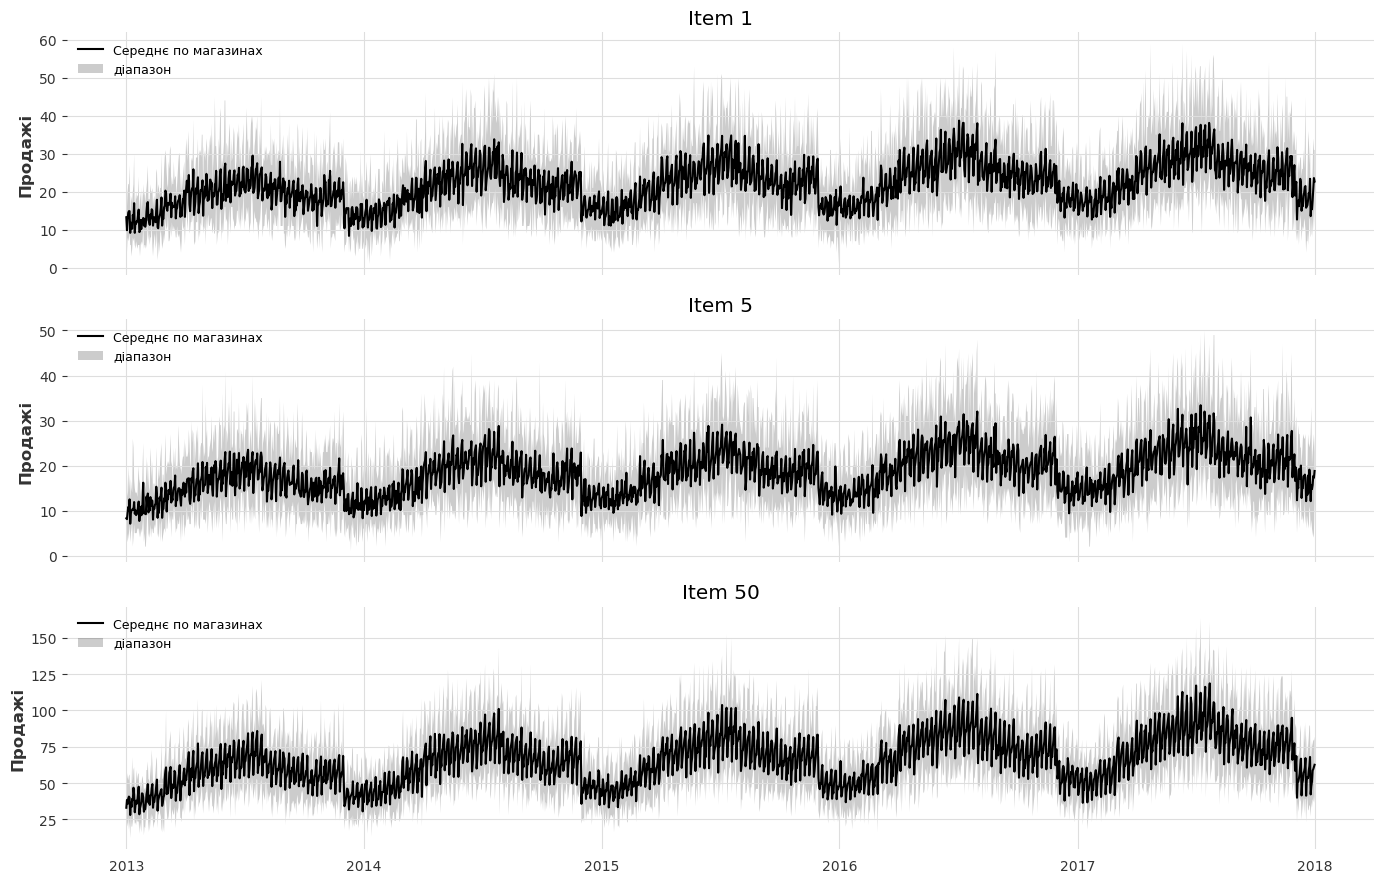

In [8]:
selected_items = [1, 5, 50]

fig, axes = plt.subplots(3, 1, 
                          figsize=(14, 9),
                          sharex=True)

for ax, item_id in zip(axes, selected_items):
    item_data = df[df['item'] == item_id]
    grouped = item_data.groupby('date')['sales']
    daily_mean = grouped.mean()
    daily_min  = grouped.min()
    daily_max  = grouped.max()
    
    ax.plot(daily_mean.index, daily_mean, 
            label='Середнє по магазинах', linewidth=1.5)
    ax.fill_between(daily_mean.index, daily_min, daily_max,
                    alpha=0.2, label='діапазон')
    
    ax.set_title(f'Item {item_id}')
    ax.set_ylabel('Продажі')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

- Всі три айтеми демонструють чіткий висхідний тренд: продажі зростають з 2013 по 2017 рік.
- Видна сезонність: влітку продажі вищі, взимку нижчі
- Діапазон між мінімальним і максимальним магазином відносно вузький, різні магазини ведуть себе схоже для одного айтему, але абсолютні рівні продажів відрізняються.

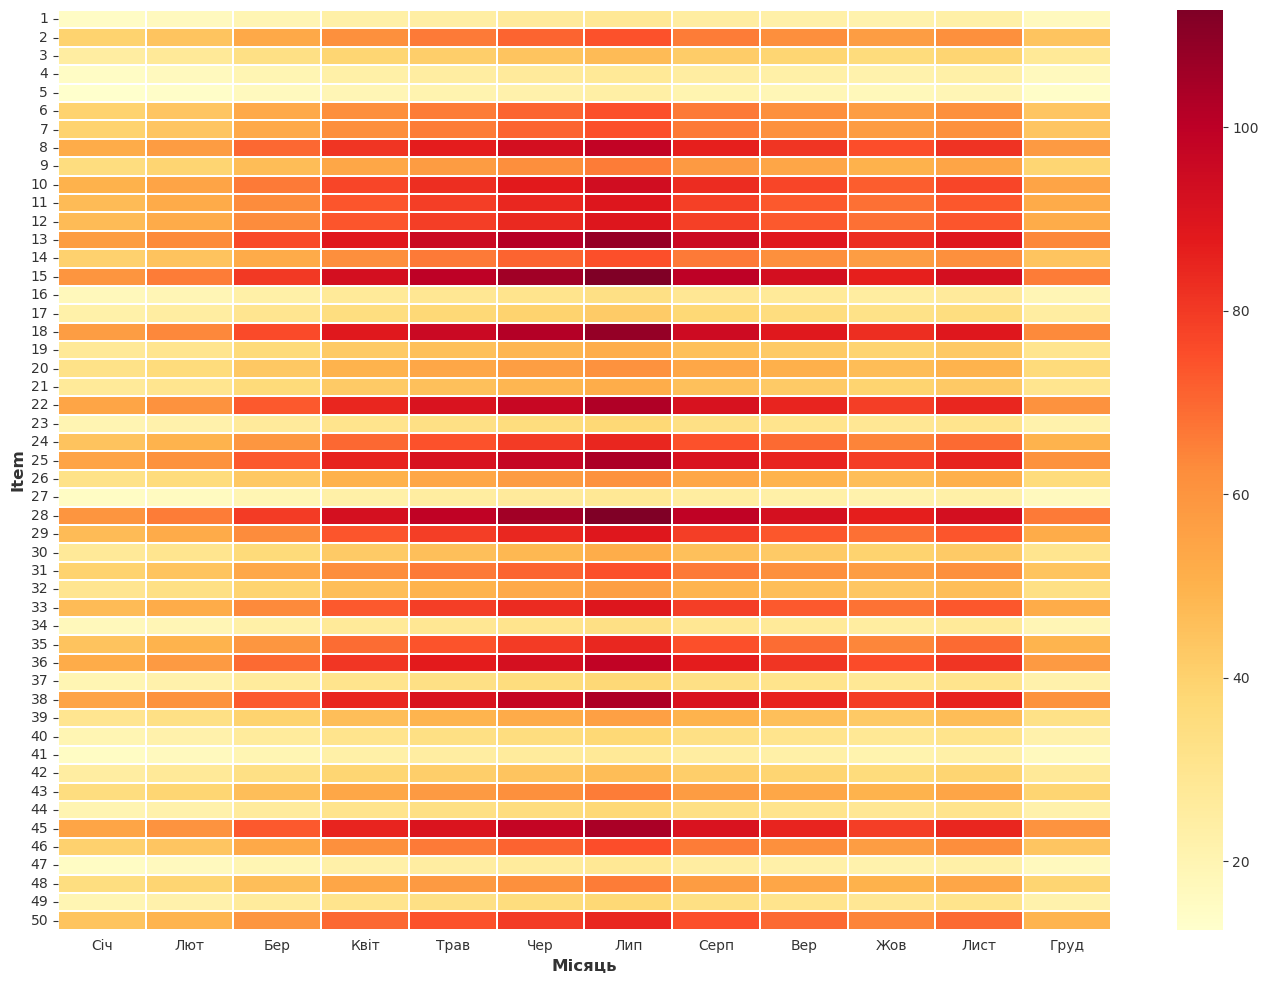

In [9]:
df['month'] = df.index.month
df['year']  = df.index.year

heatmap_data = (
    df.groupby(['item', 'month'])['sales']
    .mean()
    .unstack(level='month')  
)

month_names = ['Січ', 'Лют', 'Бер', 'Квіт', 'Трав', 'Чер',
               'Лип', 'Серп', 'Вер', 'Жов', 'Лист', 'Груд']
heatmap_data.columns = month_names

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.3,
    annot=False,
    ax=ax
)

ax.set_xlabel('Місяць')
ax.set_ylabel('Item')
plt.tight_layout()
plt.show()

- Підтверджує сезонність: літні місяці стабільно темніші по всіх айтемах.
- Деякі айтеми загалом продаються краще (горизонтальна різниця між рядками)
- Патерн сезонності однотипний для більшості айтемів

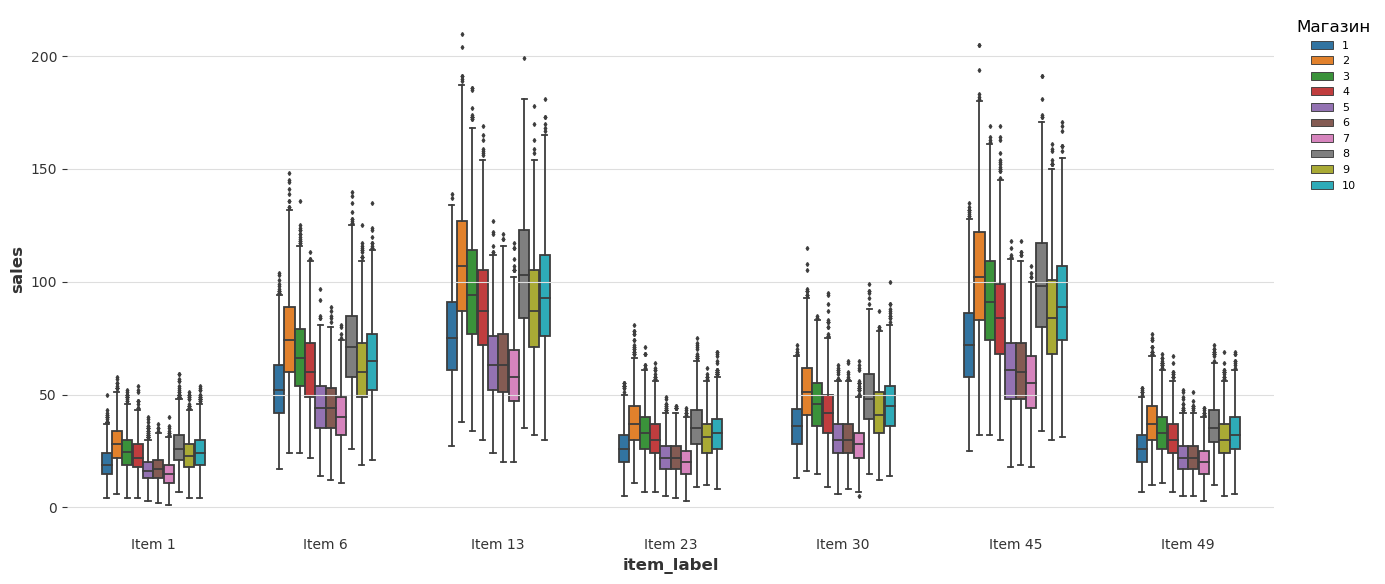

In [10]:
selected = [1, 6, 13, 23, 30, 45, 49]  

plot_data = df[df['item'].isin(selected)].copy()
plot_data['item_label'] = plot_data['item'].apply(
    lambda x: f'Item {x}'
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=plot_data,
    x='item_label',
    y='sales',
    hue='store',
    palette='tab10',
    ax=ax,
    width=0.6,
    fliersize=2
)

ax.legend(title='Магазин', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

- Розподіл продажів по магазинах для кожного айтему досить схожий
- Між магазинами є невеликі відмінності в рівні продажів, але загальний патерн зберігається

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [11]:
item1_store1 = df[(df['item'] == 1) & (df['store'] == 1)][['sales']]

In [12]:
decomposition = seasonal_decompose(item1_store1['sales'], 
                                   model='additive', 
                                   period=365)

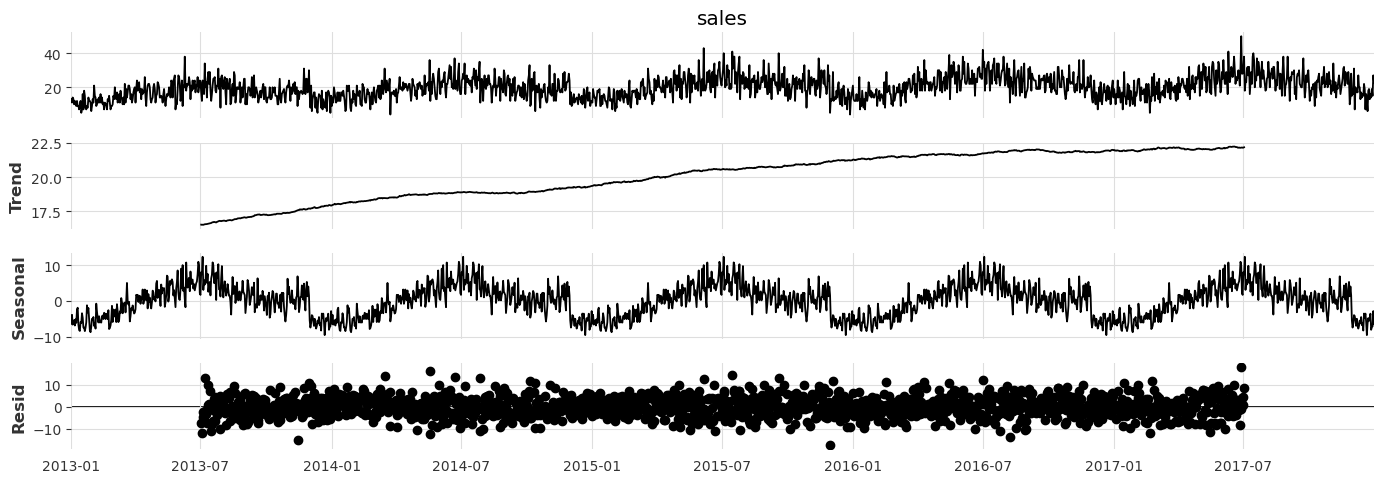

In [13]:
decomposition.plot()
plt.show()

- **Тренд**: чітко виражений висхідний тренд, продажі стабільно зростають протягом 5 років
- **Сезонність**: спостерігається річна сезонність з піками в літній період. Амплітуда сезонних коливань залишається приблизно постійною
- **Залишки**: виглядають відносно випадково навколо нуля

З точки зору обробки даних варто було б агрегувати продажі по тижнях перед декомпозицією

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [14]:
series = TimeSeries.from_dataframe(item1_store1, value_cols='sales')

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<AxesSubplot:xlabel='date'>

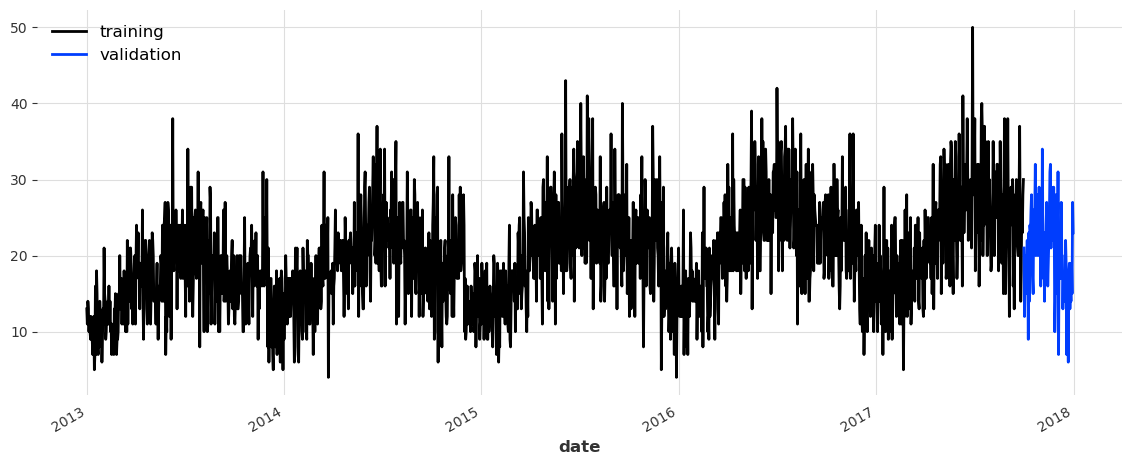

In [15]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
train.plot(label="training")
val.plot(label="validation")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

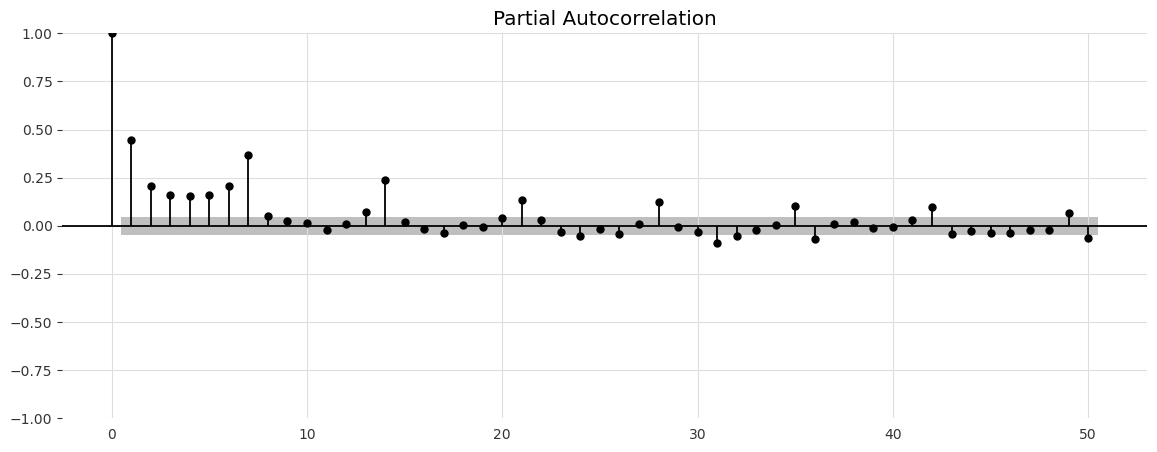

In [16]:
plot_pacf(item1_store1['sales'], lags=50, method='ywm')
plt.show()

- **Лаг 1** — найсильніший і статистично значущий. Сьогоднішні продажі дуже сильно корелюють з учорашніми.
- **Лаги 2–6** — поступово спадають, але залишаються значущими
- **Лаг 7** — різкий пік, що виходить за межі довірчого інтервалу. Це тижнева сезонність
- **Лаги 14, 21, 28** — слабші, але помітні піки кратні 7. Підтверджують тижневу структуру

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [17]:
for m in range(2, 24):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05)
    if is_seasonal:
        print(f"Сезонність: period = {period}")

Сезонність: period = 7
Сезонність: period = 14
Сезонність: period = 21


Всі вони кратні 7, це тижнева сезонність.

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

<AxesSubplot:xlabel='date'>

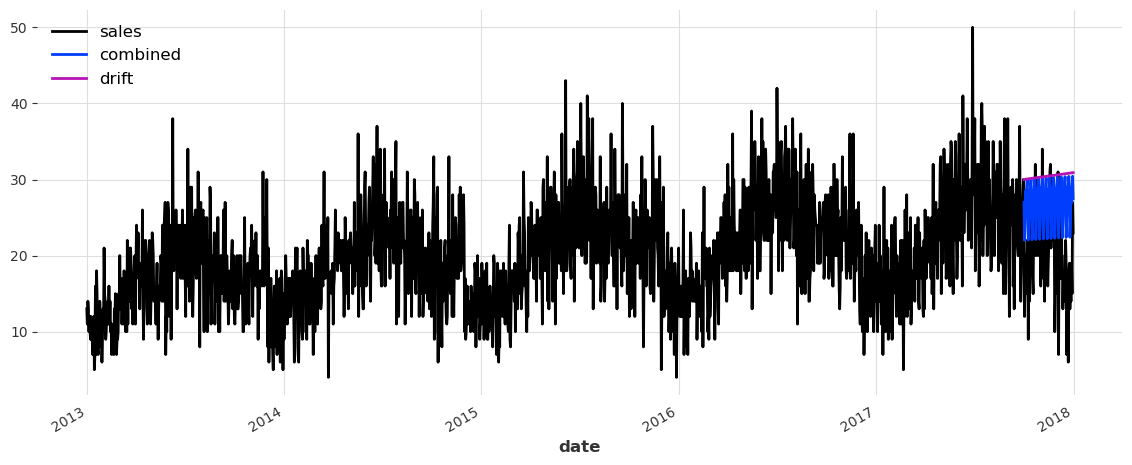

In [68]:
seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(len(val))

drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(len(val))

combined_forecast = (seasonal_forecast + drift_forecast) / 2

series.plot()
combined_forecast.plot(label="combined")
drift_forecast.plot(label="drift")

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [19]:
naive_mape = mape(val, combined_forecast)
print(f"MAPE: {naive_mape:.2f}%")

MAPE: 39.91%


модель трохи дивно вловила тренд і не сильно врахувала сезонність

10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [24]:
def eval_forecast(model, val, forecast):
  mape_ = mape(val, forecast)
  print(f"model {model} obtains MAPE: {mape_:.2f}%")
  return mape_

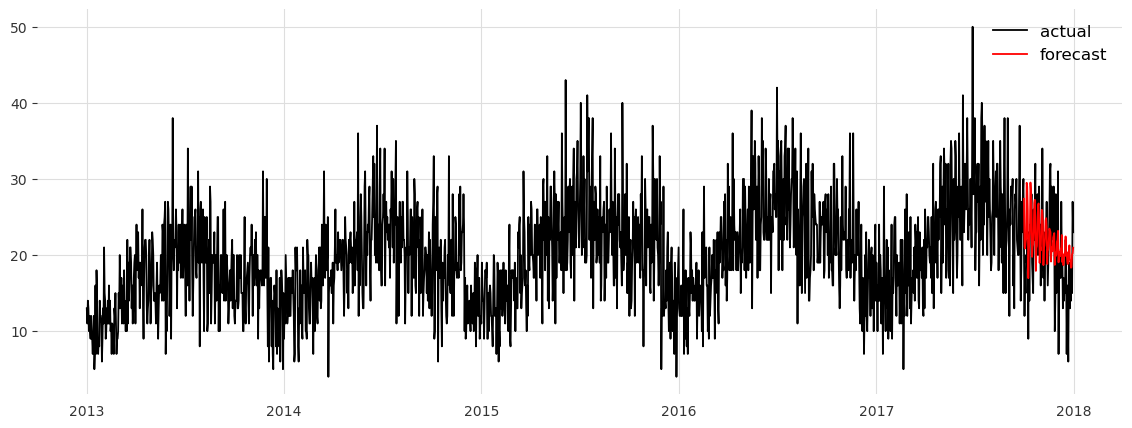

model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...) obtains MAPE: 28.58%


28.57793641895825

In [42]:
scaler = Scaler()
train_scaled = scaler.fit_transform(train)

model = XGBModel(
    lags=14,
    output_chunk_length=1,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(train_scaled)
forecast = scaler.inverse_transform(model.predict(len(val)))

plt.figure(figsize=(14, 5))
plt.plot(item1_store1.index, item1_store1['sales'], label='actual')
plt.plot(forecast.time_index, forecast.values(), label='forecast', color='red')
plt.legend()
plt.show()

eval_forecast(model, val, forecast)

тут модел краще вловила суть, маре нижчий

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

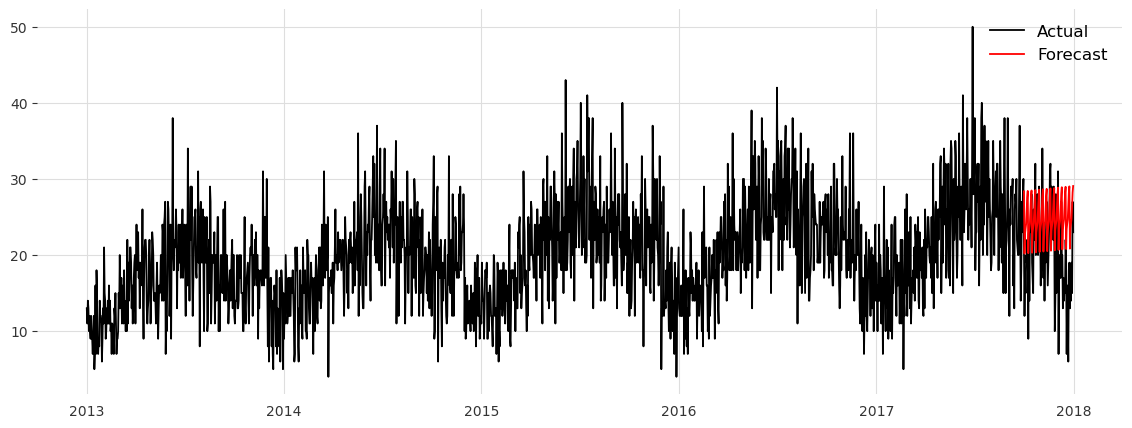

model ExponentialSmoothing() obtains MAPE: 39.01%


In [44]:
def plot_results(series, forecast):
    plt.figure(figsize=(14, 5))
    plt.plot(item1_store1.index, item1_store1['sales'], label='Actual')
    plt.plot(forecast.time_index, forecast.values(), label='Forecast', color='red')
    plt.legend()
    plt.show()

def fit_and_plot(model, series, train, val):
    model.fit(train)
    forecast = model.predict(len(val))
    plot_results(series, forecast)
    eval_forecast(model, val, forecast)

model = ExponentialSmoothing()
fit_and_plot(model, series, train, val)

Тут модель не відрізняється своїми результатами від наївної моделі

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

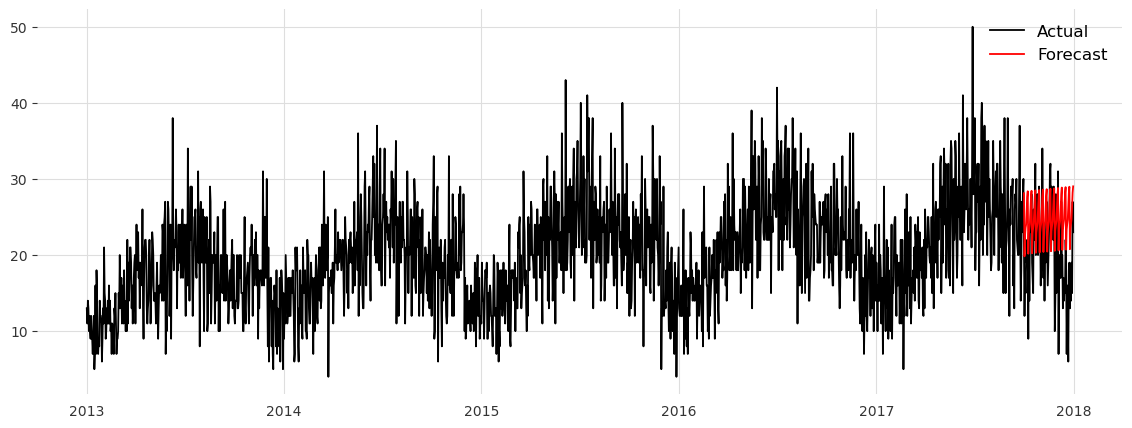

model ARIMA(p=2, q=1, seasonal_order=(1, 1, 1, 7)) obtains MAPE: 38.79%


In [66]:
model = ARIMA(p=2, d=1, q=1, seasonal_order=(1, 1, 1, 7))
fit_and_plot(model, series, train, val)

результати все ще не сильно тішать

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

AutoARIMA(add_encoders=None, quantiles=None, random_state=None, start_p=1, max_p=5, start_q=0, max_q=3, d=1, season_length=7)

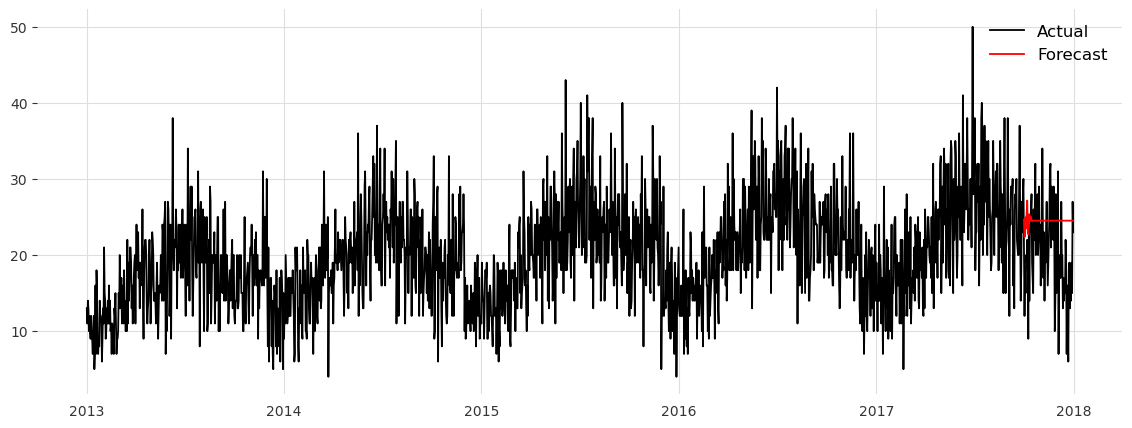

model AutoARIMA(start_p=1, max_p=5, start_q=0, max_q=3, d=1, season_length=7) obtains MAPE: 40.56%


In [71]:
model = AutoARIMA(start_p=1, max_p=5, start_q=0, max_q=3, d=1, season_length=7)
model.fit(train)
display(model)
fit_and_plot(model, series, train, val)

AutoARIMA вибрала мінімальну модель, прогноз - майже константа, результат ще гірший за попередні

14. Натренуйте модель Prophet та зробіть висновок про її якість.

00:36:08 - cmdstanpy - INFO - Chain [1] start processing
00:36:09 - cmdstanpy - INFO - Chain [1] done processing


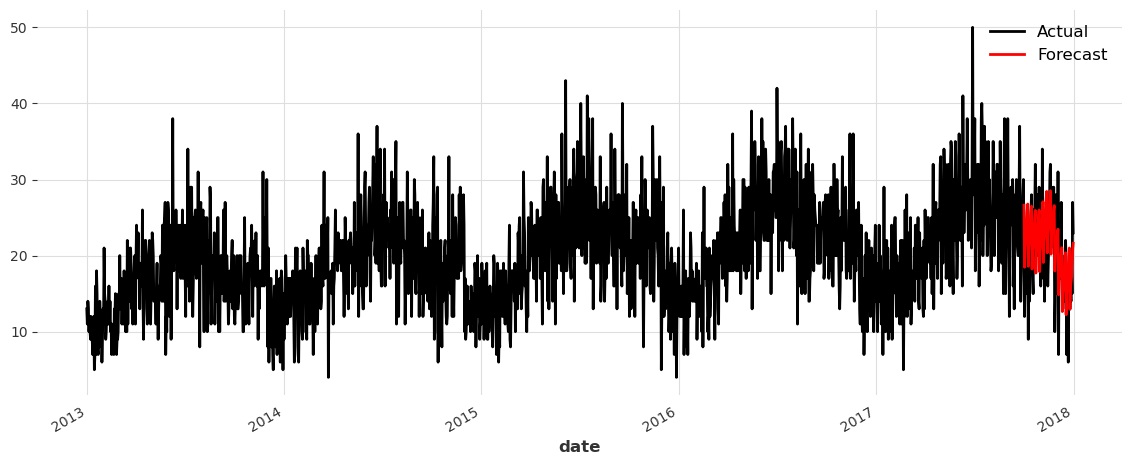

In [29]:
model = Prophet()
model.fit(train)

forecast = model.predict(len(val))

series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

In [30]:
eval_forecast(model, val, forecast);

model Prophet() obtains MAPE: 23.80%


найкращий результат!

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 2.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
2.8 K     Trainable params
0         Non-trainable params
2.8 K     Total params
0.011     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
C:\Users\Admin\anaconda3\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as

Training: |                                                                                      | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                                                                    | 0/? [00:00<…

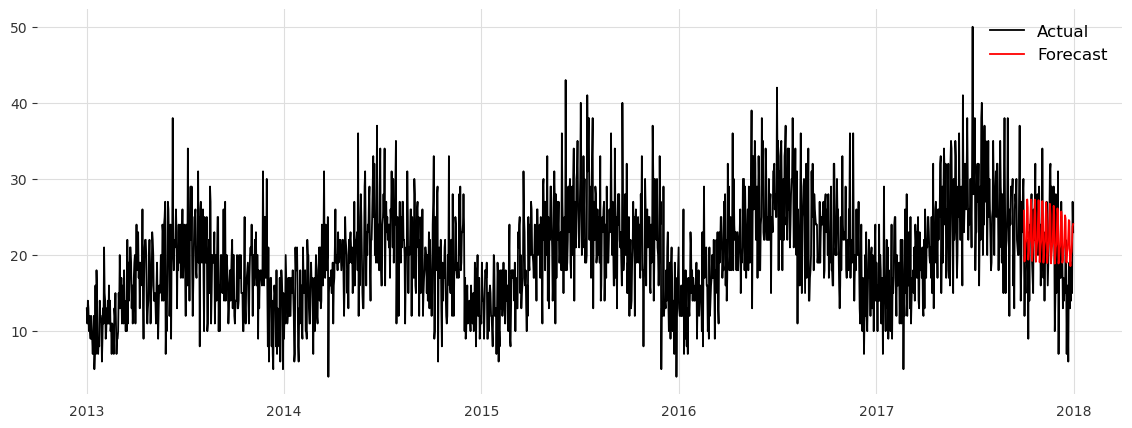

model RNNModel(model=LSTM, training_length=28, input_chunk_length=14, n_epochs=300) obtains MAPE: 29.82%


In [67]:
model = RNNModel(
    model='LSTM',
    input_chunk_length=14,
    training_length=28,
    n_epochs=300
)

fit_and_plot(model, series, train, val)

теж кращий результат але не настільки хороший як Prophet

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

historical forecasts:   0%|          | 0/336 [00:00<?, ?it/s]

00:45:14 - cmdstanpy - INFO - Chain [1] start processing
00:45:14 - cmdstanpy - INFO - Chain [1] done processing
00:45:14 - cmdstanpy - INFO - Chain [1] start processing
00:45:15 - cmdstanpy - INFO - Chain [1] done processing
00:45:15 - cmdstanpy - INFO - Chain [1] start processing
00:45:15 - cmdstanpy - INFO - Chain [1] done processing
00:45:15 - cmdstanpy - INFO - Chain [1] start processing
00:45:15 - cmdstanpy - INFO - Chain [1] done processing
00:45:15 - cmdstanpy - INFO - Chain [1] start processing
00:45:16 - cmdstanpy - INFO - Chain [1] done processing
00:45:16 - cmdstanpy - INFO - Chain [1] start processing
00:45:16 - cmdstanpy - INFO - Chain [1] done processing
00:45:16 - cmdstanpy - INFO - Chain [1] start processing
00:45:16 - cmdstanpy - INFO - Chain [1] done processing
00:45:16 - cmdstanpy - INFO - Chain [1] start processing
00:45:17 - cmdstanpy - INFO - Chain [1] done processing
00:45:17 - cmdstanpy - INFO - Chain [1] start processing
00:45:17 - cmdstanpy - INFO - Chain [1]

00:45:40 - cmdstanpy - INFO - Chain [1] done processing
00:45:40 - cmdstanpy - INFO - Chain [1] start processing
00:45:40 - cmdstanpy - INFO - Chain [1] done processing
00:45:41 - cmdstanpy - INFO - Chain [1] start processing
00:45:41 - cmdstanpy - INFO - Chain [1] done processing
00:45:41 - cmdstanpy - INFO - Chain [1] start processing
00:45:41 - cmdstanpy - INFO - Chain [1] done processing
00:45:41 - cmdstanpy - INFO - Chain [1] start processing
00:45:41 - cmdstanpy - INFO - Chain [1] done processing
00:45:42 - cmdstanpy - INFO - Chain [1] start processing
00:45:42 - cmdstanpy - INFO - Chain [1] done processing
00:45:42 - cmdstanpy - INFO - Chain [1] start processing
00:45:42 - cmdstanpy - INFO - Chain [1] done processing
00:45:42 - cmdstanpy - INFO - Chain [1] start processing
00:45:43 - cmdstanpy - INFO - Chain [1] done processing
00:45:43 - cmdstanpy - INFO - Chain [1] start processing
00:45:43 - cmdstanpy - INFO - Chain [1] done processing
00:45:43 - cmdstanpy - INFO - Chain [1] 

00:46:08 - cmdstanpy - INFO - Chain [1] done processing
00:46:08 - cmdstanpy - INFO - Chain [1] start processing
00:46:09 - cmdstanpy - INFO - Chain [1] done processing
00:46:09 - cmdstanpy - INFO - Chain [1] start processing
00:46:09 - cmdstanpy - INFO - Chain [1] done processing
00:46:09 - cmdstanpy - INFO - Chain [1] start processing
00:46:09 - cmdstanpy - INFO - Chain [1] done processing
00:46:10 - cmdstanpy - INFO - Chain [1] start processing
00:46:10 - cmdstanpy - INFO - Chain [1] done processing
00:46:10 - cmdstanpy - INFO - Chain [1] start processing
00:46:10 - cmdstanpy - INFO - Chain [1] done processing
00:46:10 - cmdstanpy - INFO - Chain [1] start processing
00:46:10 - cmdstanpy - INFO - Chain [1] done processing
00:46:11 - cmdstanpy - INFO - Chain [1] start processing
00:46:11 - cmdstanpy - INFO - Chain [1] done processing
00:46:11 - cmdstanpy - INFO - Chain [1] start processing
00:46:11 - cmdstanpy - INFO - Chain [1] done processing
00:46:11 - cmdstanpy - INFO - Chain [1] 

00:46:34 - cmdstanpy - INFO - Chain [1] done processing
00:46:35 - cmdstanpy - INFO - Chain [1] start processing
00:46:35 - cmdstanpy - INFO - Chain [1] done processing
00:46:35 - cmdstanpy - INFO - Chain [1] start processing
00:46:35 - cmdstanpy - INFO - Chain [1] done processing
00:46:35 - cmdstanpy - INFO - Chain [1] start processing
00:46:36 - cmdstanpy - INFO - Chain [1] done processing
00:46:36 - cmdstanpy - INFO - Chain [1] start processing
00:46:36 - cmdstanpy - INFO - Chain [1] done processing
00:46:36 - cmdstanpy - INFO - Chain [1] start processing
00:46:36 - cmdstanpy - INFO - Chain [1] done processing
00:46:37 - cmdstanpy - INFO - Chain [1] start processing
00:46:37 - cmdstanpy - INFO - Chain [1] done processing
00:46:37 - cmdstanpy - INFO - Chain [1] start processing
00:46:37 - cmdstanpy - INFO - Chain [1] done processing
00:46:37 - cmdstanpy - INFO - Chain [1] start processing
00:46:37 - cmdstanpy - INFO - Chain [1] done processing
00:46:38 - cmdstanpy - INFO - Chain [1] 

00:47:02 - cmdstanpy - INFO - Chain [1] done processing
00:47:02 - cmdstanpy - INFO - Chain [1] start processing
00:47:02 - cmdstanpy - INFO - Chain [1] done processing
00:47:02 - cmdstanpy - INFO - Chain [1] start processing
00:47:02 - cmdstanpy - INFO - Chain [1] done processing
00:47:03 - cmdstanpy - INFO - Chain [1] start processing
00:47:03 - cmdstanpy - INFO - Chain [1] done processing
00:47:03 - cmdstanpy - INFO - Chain [1] start processing
00:47:03 - cmdstanpy - INFO - Chain [1] done processing
00:47:03 - cmdstanpy - INFO - Chain [1] start processing
00:47:04 - cmdstanpy - INFO - Chain [1] done processing
00:47:04 - cmdstanpy - INFO - Chain [1] start processing
00:47:04 - cmdstanpy - INFO - Chain [1] done processing
00:47:04 - cmdstanpy - INFO - Chain [1] start processing
00:47:04 - cmdstanpy - INFO - Chain [1] done processing
00:47:04 - cmdstanpy - INFO - Chain [1] start processing
00:47:05 - cmdstanpy - INFO - Chain [1] done processing
00:47:05 - cmdstanpy - INFO - Chain [1] 

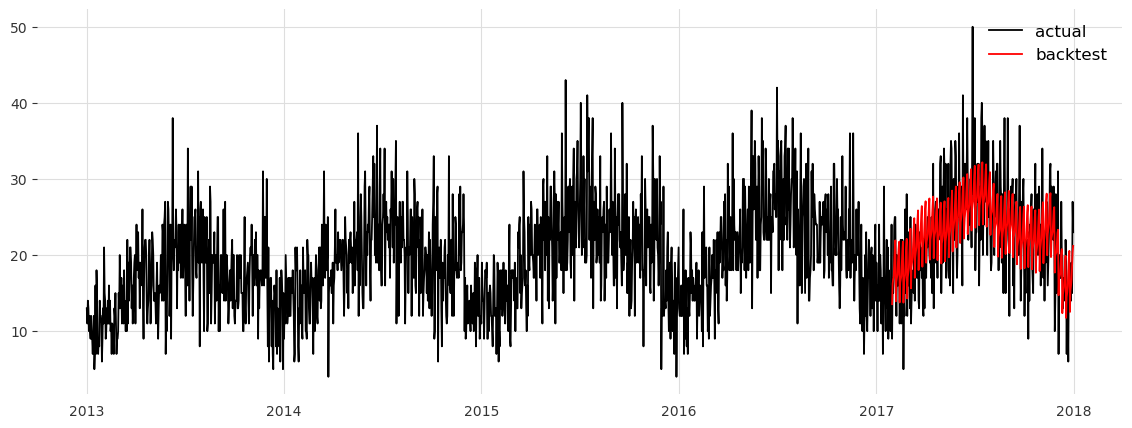

MAPE бектесту: 20.36%


In [34]:
model = Prophet()

historical_fcast = model.historical_forecasts(
    series=series,
    start=pd.Timestamp("2017-01-01"),
    forecast_horizon=30,
    verbose=True
)

plt.figure(figsize=(14, 5))
plt.plot(item1_store1.index, item1_store1['sales'], label='actual')
plt.plot(historical_fcast.time_index, historical_fcast.values(), label='backtest', color='red')
plt.legend()
plt.show()

print(f"MAPE бектесту: {mape(series, historical_fcast):.2f}%")

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Я б використала Prophet як основну модель, він автоматично моделює тренд і обидві сезонності (тижневу і річну)
Тренувала би 500 окремих моделей (50 айтемів × 10 магазинів): по одній на кожну комбінацію. Альтернативно можна натренувати одну глобальну XGBoost модель, додавши store і item як категоріальні ознаки

Prophet стійкий до пропусків, не потребує стаціонарності і добре масштабується